# Human breast cancer preprocess

Prepare the data for training.


## Settings


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents)
                    if (path / "experiments").is_dir() and (path / "lrpairs").is_dir())
sys.path.insert(0, str(PROJECT_ROOT / "experiments"))

scanvi_train_kwargs = {"accelerator": "gpu", "devices": 1, "enable_progress_bar": False}
from pathlib import Path
import sys
import yaml
CWD = Path.cwd().resolve()
EXPERIMENT_DIR = CWD if (CWD / "config.yaml").is_file() else CWD / "experiments" / "human_breast_cancer"

CONFIG = yaml.safe_load((EXPERIMENT_DIR / "config.yaml").read_text())
def experiment_path(value):
    path = Path(value)
    return path if path.is_absolute() else EXPERIMENT_DIR / path


from _shared.preprocess_plots import annotation_palette, sample_panels, alignment_overlay, embedding_panels


In [2]:
import scanpy as sc
import numpy as np
from sklearn.preprocessing import StandardScaler
from stvirtual.data.protein import prepare_protein
from stvirtual.data.contracts import canonicalize_celltypes
adata = sc.read_h5ad(experiment_path(CONFIG["input_path"]))
for key in ["sample", CONFIG["celltype_source_key"]]:
    if key not in adata.obs or adata.obs[key].isna().any():
        raise ValueError(f"Missing or incomplete annotation: {key}")
adata.obs["sample"] = adata.obs["sample"].astype(str)
if CONFIG["protein_layer"] not in adata.layers:
    raw = adata.layers["raw"] if "raw" in adata.layers else adata.X
    raw = raw.toarray() if hasattr(raw, "toarray") else np.asarray(raw)
    adata.layers["raw"] = raw.copy()
    adata.layers["asinh"] = np.arcsinh(raw / 5.0)
    adata.layers[CONFIG["protein_layer"]] = StandardScaler().fit_transform(adata.layers["asinh"])
prepare_protein(adata, layer=CONFIG["protein_layer"], feature_key=CONFIG["latent_key"])
xy = np.asarray(adata.obsm["spatial"], dtype=np.float32)
if xy.shape != (adata.n_obs, 2) or not np.isfinite(xy).all():
    raise ValueError("IMC spatial coordinates must be finite and 2D")
adata.obs["cx_aligned"], adata.obs["cy_aligned"] = xy[:, 0], xy[:, 1]
mapping = canonicalize_celltypes(adata, source_key=CONFIG["celltype_source_key"])
output = experiment_path(CONFIG["prepared_path"])
output.parent.mkdir(parents=True, exist_ok=True)
adata.write_h5ad(output, compression="gzip")
mapping.to_csv(output.parent / "celltype_mapping.csv", index=False)
print(output, adata.obsm["X_protein"].shape)


/home/zhouyj/stVirtual_tutorial/experiments/human_breast_cancer/artifacts/preprocessing/imc.h5ad (106706, 25)


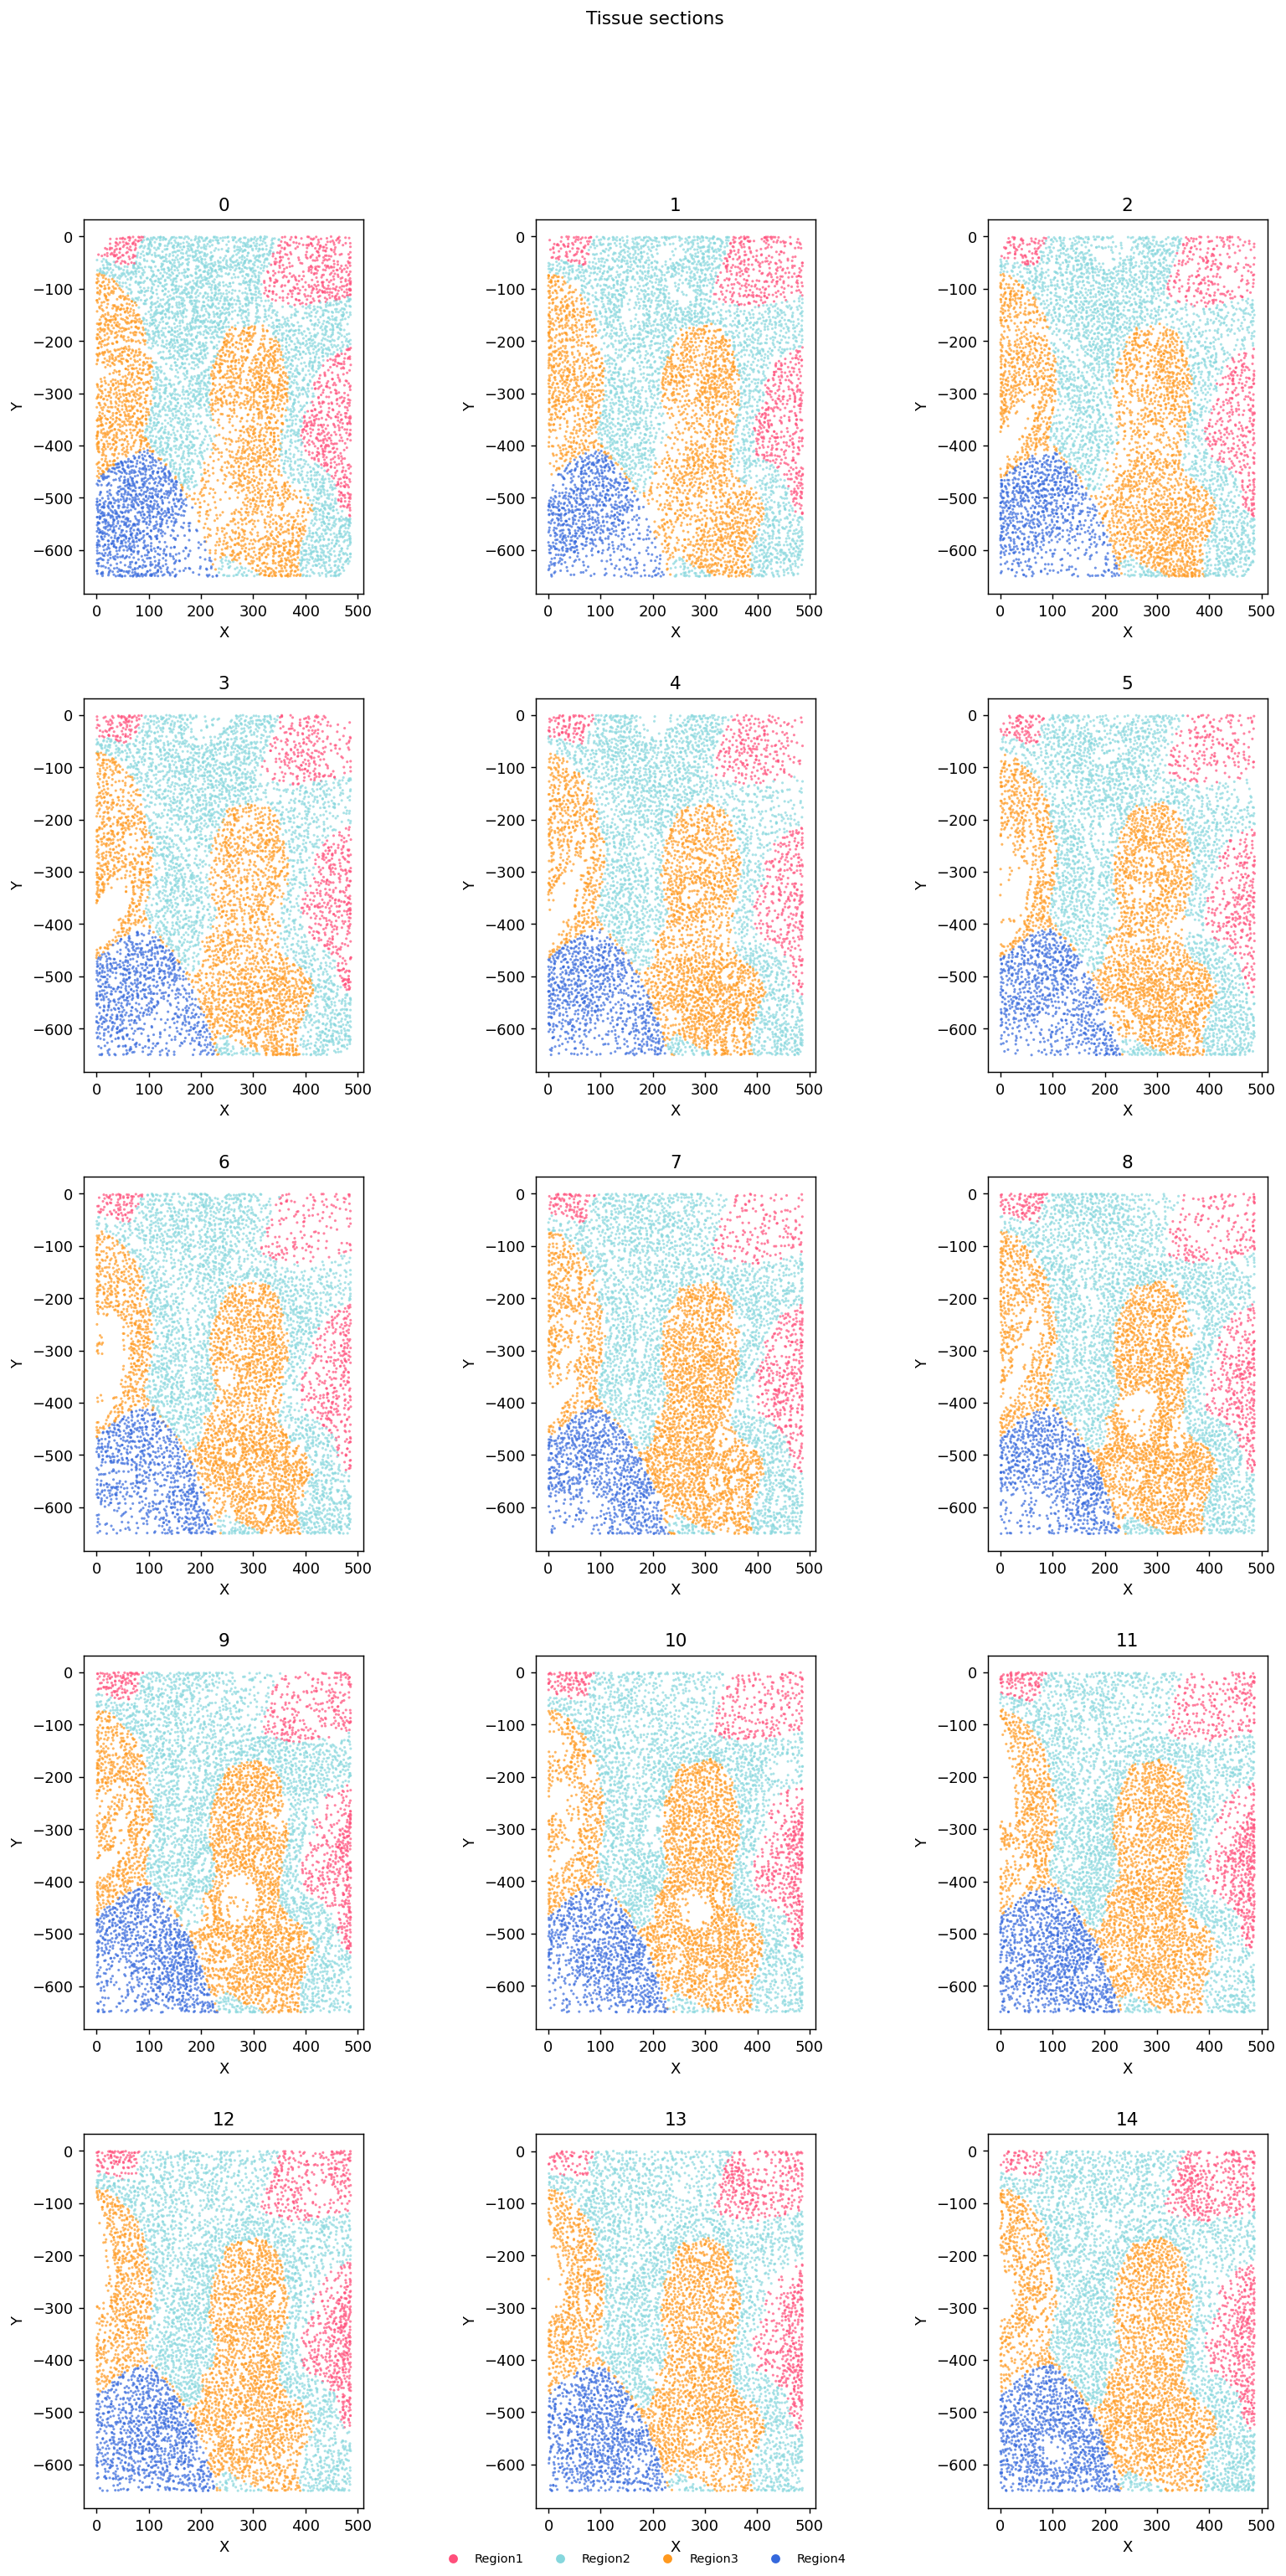

In [3]:
palette = annotation_palette(adata, CONFIG["celltype_source_key"], EXPERIMENT_DIR / "colors.json")
sample_panels(adata, adata.obsm["spatial"], "sample", CONFIG["celltype_source_key"], palette, title="Tissue sections", size=3);
